# 📊 Data Understanding — California Housing Dataset

**Objetivo:** Análisis exploratorio y validación del dataset de viviendas de California.  
Cubre controles de calidad, validación de supuestos, detección de riesgos y resumen ejecutivo.

**Granularidad:** Bloque censal (cada fila = un bloque censal)  
**Alcance geográfico:** Estado de California, EE.UU.  
**Fuente:** Censo de EE.UU. 1990 (popularizado por Aurélien Géron)  
**Variable objetivo:** `median_house_value`

---

## 0. Configuración general
Ajusta las variables de esta celda antes de ejecutar el notebook.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Ruta al fichero de datos (ajustar según entorno) ──────────────────────────
RUTA_DATOS = "../data/housing.csv"   # ← CAMBIAR por la ruta real

# ── Separador del CSV ─────────────────────────────────────────────────────────
SEPARADOR = ","

# ── No existe clave compuesta natural; se usará el índice como identificador ──
# Nota: cada fila representa un bloque censal, sin ID único explícito.
CLAVE_UNICA = []  # Sin clave compuesta declarada en este dataset

# ── Campos geográficos y categóricos a revisar ────────────────────────────────
CAMPOS_CATEGORICOS = ["ocean_proximity"]

# ── No hay campos de fecha en este dataset ────────────────────────────────────
CAMPOS_FECHA = []  # Sin campos de fecha

# ── Campos numéricos de resultado / target ────────────────────────────────────
CAMPOS_RESULTADO = ["median_house_value", "median_income"]

# ── Todos los campos numéricos ────────────────────────────────────────────────
CAMPOS_NUMERICOS = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population",
    "households", "median_income", "median_house_value"
]

# ── Umbrales de valores capados detectados en análisis previo ─────────────────
CAP_HOUSE_VALUE = 500_001   # Valor techo en median_house_value
CAP_MEDIAN_AGE  = 52        # Valor techo en housing_median_age


## 1. Carga del dataset

In [26]:
try:
    df = pd.read_csv(RUTA_DATOS, sep=SEPARADOR, low_memory=False)
    print(f"✔ Dataset cargado correctamente.")
    print(f"  - Filas:    {df.shape[0]:,}")
    print(f"  - Columnas: {df.shape[1]}")
    print(f"\n  Columnas disponibles:")
    print(list(df.columns))
except FileNotFoundError:
    print(f"✘ ERROR: No se encontró el fichero '{RUTA_DATOS}'.")
    print("  Ajusta la variable RUTA_DATOS con la ruta correcta.")
    raise


✔ Dataset cargado correctamente.
  - Filas:    20,640
  - Columnas: 10

  Columnas disponibles:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


## 2. Visión general del dataset

In [27]:
# Tipos de datos por columna
print("--- Tipos de datos ---")
df.info()


--- Tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [28]:
# Primeras 5 filas del dataset
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Control de calidad: Completitud (nulos por campo)

In [29]:
# Porcentaje de nulos por campo, ordenado de mayor a menor
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

df_nulos = pd.DataFrame({
    "Nulos": nulos,
    "% Nulos": pct_nulos
}).sort_values("% Nulos", ascending=False)

print("--- Campos con valores nulos ---")
display(df_nulos[df_nulos["Nulos"] > 0])

if df_nulos["Nulos"].sum() == 0:
    print("✔ No se detectan nulos en el dataset.")


--- Campos con valores nulos ---


,Nulos,% Nulos
total_bedrooms,207,1.0


In [30]:
# Muestra los registros con valor nulo
# Nota: solo total_bedrooms tiene nulos (207 registros, ~1%)
print("--- Registros con valores nulos ---")
for campo in df.columns:
    if df[campo].isnull().any():
        print(f"\nCampo: {campo} - Nulos: {df[campo].isnull().sum()}")
        display(df[df[campo].isnull()].head(10))


--- Registros con valores nulos ---

Campo: total_bedrooms - Nulos: 207


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


In [31]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [32]:
# Completitud de campos numéricos clave
# Umbral de alerta: > 5% de nulos
print("--- Completitud de campos numéricos ---")
for campo in CAMPOS_NUMERICOS:
    if campo in df.columns:
        pct = df[campo].isnull().mean() * 100
        estado = "⚠ REVISAR" if pct > 5 else ("⚠ LEVE" if pct > 0 else "✔ OK")
        print(f"  {campo:<25} → {pct:.2f}% nulos  {estado}")

print("\n--- Completitud de campo categórico ---")
for campo in CAMPOS_CATEGORICOS:
    if campo in df.columns:
        pct = df[campo].isnull().mean() * 100
        estado = "⚠ REVISAR" if pct > 1 else "✔ OK"
        print(f"  {campo:<25} → {pct:.2f}% nulos  {estado}")


--- Completitud de campos numéricos ---
  longitude                 → 0.00% nulos  ✔ OK
  latitude                  → 0.00% nulos  ✔ OK
  housing_median_age        → 0.00% nulos  ✔ OK
  total_rooms               → 0.00% nulos  ✔ OK
  total_bedrooms            → 1.00% nulos  ⚠ LEVE
  population                → 0.00% nulos  ✔ OK
  households                → 0.00% nulos  ✔ OK
  median_income             → 0.00% nulos  ✔ OK
  median_house_value        → 0.00% nulos  ✔ OK

--- Completitud de campo categórico ---
  ocean_proximity           → 0.00% nulos  ✔ OK


## 4. Control de calidad: Unicidad de registros

> Este dataset no tiene una clave compuesta declarada. Cada fila representa un bloque censal;  
> se verifican duplicados exactos sobre todas las columnas.


In [33]:
# Verificar duplicados exactos (todas las columnas)
total_filas = len(df)
duplicados = df.duplicated().sum()

print(f"  Total de filas:          {total_filas:,}")
print(f"  Filas duplicadas:        {duplicados:,}")

if duplicados == 0:
    print("  ✔ No se detectan duplicados exactos en el dataset.")
else:
    print(f"  ⚠ ALERTA: {duplicados:,} duplicados detectados. Revisar antes de analizar.")
    display(df[df.duplicated(keep=False)].head(10))


  Total de filas:          20,640
  Filas duplicadas:        0
  ✔ No se detectan duplicados exactos en el dataset.


## 5. Control de calidad: Validez de rangos en variables numéricas

In [34]:
# Estadísticas descriptivas de todas las variables numéricas
display(df[CAMPOS_NUMERICOS].describe().T.round(2))

# ── Detección de valores capados (truncamientos del censo) ────────────────────
print("\n--- Detección de valores techo (censados artificialmente) ---")

n_cap_value = (df["median_house_value"] == CAP_HOUSE_VALUE).sum()
pct_cap_value = n_cap_value / len(df) * 100
print(f"  median_house_value == {CAP_HOUSE_VALUE:,}: {n_cap_value:,} registros ({pct_cap_value:.1f}%)")
if n_cap_value > 0:
    print("  ⚠ ALERTA: Valor techo detectado. Distorsiona modelos en el rango alto. Considerar excluir.")

n_cap_age = (df["housing_median_age"] == CAP_MEDIAN_AGE).sum()
pct_cap_age = n_cap_age / len(df) * 100
print(f"\n  housing_median_age == {CAP_MEDIAN_AGE}: {n_cap_age:,} registros ({pct_cap_age:.1f}%)")
if n_cap_age > 0:
    print("  ⚠ ALERTA: Posible valor techo en edad de vivienda. Validar con fuente.")

# ── Valores negativos (no esperados) ──────────────────────────────────────────
print("\n--- Detección de valores negativos ---")
for campo in ["total_rooms", "total_bedrooms", "population", "households",
               "median_income", "median_house_value", "housing_median_age"]:
    if campo in df.columns:
        n_neg = (df[campo] < 0).sum()
        if n_neg > 0:
            print(f"  ⚠ {campo}: {n_neg:,} valores negativos. Revisar.")
        else:
            print(f"  ✔ {campo}: sin valores negativos.")


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00



--- Detección de valores techo (censados artificialmente) ---
  median_house_value == 500,001: 965 registros (4.7%)
  ⚠ ALERTA: Valor techo detectado. Distorsiona modelos en el rango alto. Considerar excluir.

  housing_median_age == 52: 1,273 registros (6.2%)
  ⚠ ALERTA: Posible valor techo en edad de vivienda. Validar con fuente.

--- Detección de valores negativos ---
  ✔ total_rooms: sin valores negativos.
  ✔ total_bedrooms: sin valores negativos.
  ✔ population: sin valores negativos.
  ✔ households: sin valores negativos.
  ✔ median_income: sin valores negativos.
  ✔ median_house_value: sin valores negativos.
  ✔ housing_median_age: sin valores negativos.


## 6. Riesgo de sesgo: variables brutas vs. ratios por hogar

> ⚠️ **Riesgo crítico:** `total_rooms`, `total_bedrooms` y `population` están a nivel de **bloque censal**  
> y no son comparables directamente entre bloques de distinto tamaño.  
> **Siempre normalizar por `households` antes de comparar o modelar.**


In [35]:
# Crear ratios normalizados por hogar
df["rooms_per_household"]    = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]      = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]   / df["households"]

print("  Estadísticas de ratios derivados:")
display(df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe().T.round(3))

# Detectar valores extremos en ratios (posibles errores de datos)
print("\n  ⚠ Outliers en ratios (percentil 99):")
for r in ["rooms_per_household", "bedrooms_per_room", "population_per_household"]:
    p99 = df[r].quantile(0.99)
    n_out = (df[r] > p99).sum()
    print(f"    {r:<35}: p99 = {p99:.2f}  |  registros sobre p99: {n_out}")


  Estadísticas de ratios derivados:


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
bedrooms_per_room,20433.0,0.213,0.058,0.100,0.175,0.203,0.240,1.000
population_per_household,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333



  ⚠ Outliers en ratios (percentil 99):
    rooms_per_household                : p99 = 10.36  |  registros sobre p99: 207
    bedrooms_per_room                  : p99 = 0.41  |  registros sobre p99: 205
    population_per_household           : p99 = 5.39  |  registros sobre p99: 207


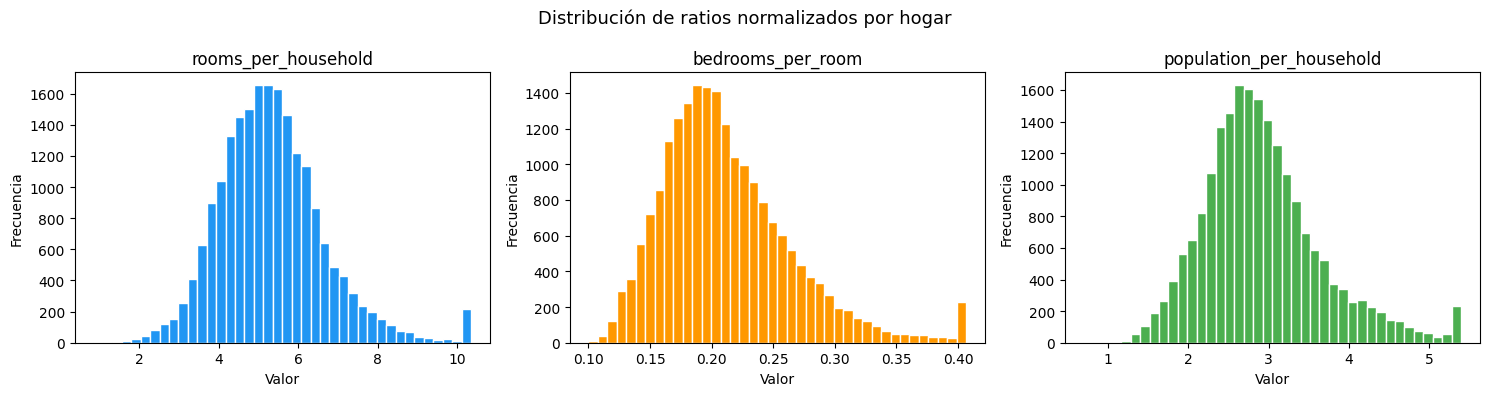

In [36]:
# Distribución de los ratios derivados
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribución de ratios normalizados por hogar", fontsize=13)
for ax, col, color in zip(axes,
    ["rooms_per_household", "bedrooms_per_room", "population_per_household"],
    ["#2196F3", "#FF9800", "#4CAF50"]):
    ax.hist(df[col].clip(upper=df[col].quantile(0.99)), bins=40, color=color, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 7. Dominio de variables categóricas

In [37]:
# Revisión del campo categórico ocean_proximity
for campo in CAMPOS_CATEGORICOS:
    if campo in df.columns:
        valores = df[campo].value_counts(dropna=False)
        print(f"{'─'*50}")
        print(f"  {campo}  ({df[campo].nunique(dropna=True)} valores únicos)")
        print(f"{'─'*50}")
        display(valores.rename("Frecuencia").to_frame())

        # Alerta por categorías minoritarias
        minoria = valores[valores < 10]
        if not minoria.empty:
            print(f"  ⚠ Categorías con < 10 registros: {list(minoria.index)}")
            print("    Considerar fusionar o excluir antes de modelar.")


──────────────────────────────────────────────────
  ocean_proximity  (5 valores únicos)
──────────────────────────────────────────────────


,Frecuencia
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


  ⚠ Categorías con < 10 registros: ['ISLAND']
    Considerar fusionar o excluir antes de modelar.


## 8. Análisis de distribución y asimetría

> Las variables de conteo (rooms, bedrooms, population) presentan alta asimetría positiva.  
> Se recomienda transformación logarítmica antes de usar modelos lineales.


In [38]:
# Cálculo del coeficiente de asimetría (skewness) por variable
skew = df[CAMPOS_NUMERICOS].skew().sort_values(ascending=False).round(2)
print("  Skewness por variable (|skew| > 1 = asimetría significativa):")
for col, val in skew.items():
    alerta = "⚠ ALTA" if abs(val) > 2 else ("⚠ MOD" if abs(val) > 1 else "✔ OK")
    print(f"    {col:<25}: {val:>6.2f}  {alerta}")


  Skewness por variable (|skew| > 1 = asimetría significativa):
    population               :   4.94  ⚠ ALTA
    total_rooms              :   4.15  ⚠ ALTA
    total_bedrooms           :   3.46  ⚠ ALTA
    households               :   3.41  ⚠ ALTA
    median_income            :   1.65  ⚠ MOD
    median_house_value       :   0.98  ✔ OK
    latitude                 :   0.47  ✔ OK
    housing_median_age       :   0.06  ✔ OK
    longitude                :  -0.30  ✔ OK


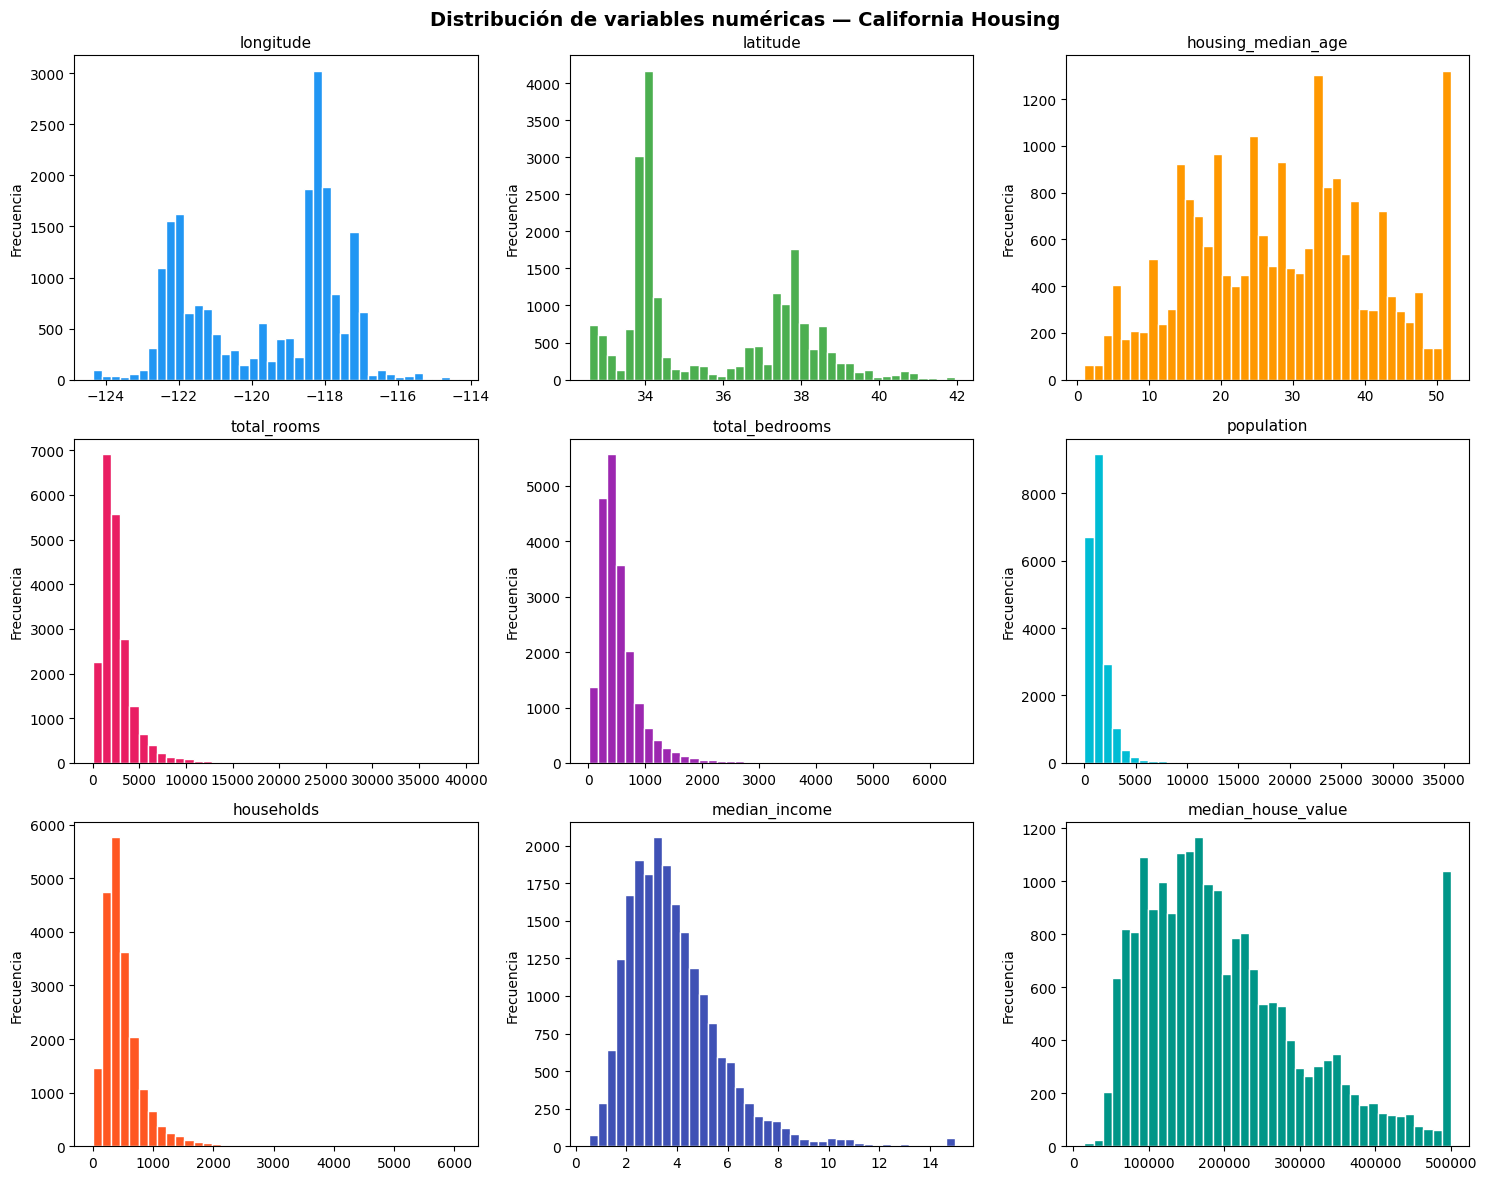

In [39]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Distribución de variables numéricas — California Housing", fontsize=14, fontweight="bold")
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4", "#FF5722", "#3F51B5", "#009688"]
for ax, col, color in zip(axes.flat, CAMPOS_NUMERICOS, colors):
    ax.hist(df[col].dropna(), bins=40, color=color, edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 9. Análisis exploratorio: Variable objetivo y predictores clave

In [40]:
# Estadísticas del target: median_house_value
print("  Estadísticas de median_house_value:")
display(df["median_house_value"].describe().to_frame().T.round(0))

# Distribución excluyendo el valor techo
df_no_cap = df[df["median_house_value"] < CAP_HOUSE_VALUE]
print(f"\n  Sin registros capados (n={len(df_no_cap):,}):")
display(df_no_cap["median_house_value"].describe().to_frame().T.round(0))


  Estadísticas de median_house_value:


,count,mean,std,min,25%,50%,75%,max
median_house_value,20640.0,206856.0,115396.0,14999.0,119600.0,179700.0,264725.0,500001.0



  Sin registros capados (n=19,675):


,count,mean,std,min,25%,50%,75%,max
median_house_value,19675.0,192478.0,97712.0,14999.0,116600.0,173800.0,248200.0,500000.0


In [41]:
# Media de median_house_value por ocean_proximity
if "ocean_proximity" in df.columns:
    media_ocean = df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False)
    print("  Media de median_house_value por ocean_proximity:")
    display(media_ocean.round(0).rename("Media $").to_frame())


  Media de median_house_value por ocean_proximity:


,Media $
ocean_proximity,
ISLAND,380440.0
NEAR BAY,259212.0
NEAR OCEAN,249434.0
<1H OCEAN,240084.0
INLAND,124805.0


In [42]:
# Evolución de median_house_value según tramos de median_income
df["income_tramo"] = pd.qcut(df["median_income"], q=5,
    labels=["Q1 (bajo)", "Q2", "Q3 (medio)", "Q4", "Q5 (alto)"])
evolucion_income = df.groupby("income_tramo")["median_house_value"].mean()
print("  Media de median_house_value por quintil de median_income:")
display(evolucion_income.round(0).rename("Media $").to_frame())


  Media de median_house_value por quintil de median_income:


,Media $
income_tramo,
Q1 (bajo),118403.0
Q2,157030.0
Q3 (medio),193890.0
Q4,230029.0
Q5 (alto),334991.0


## 10. Visualizaciones básicas

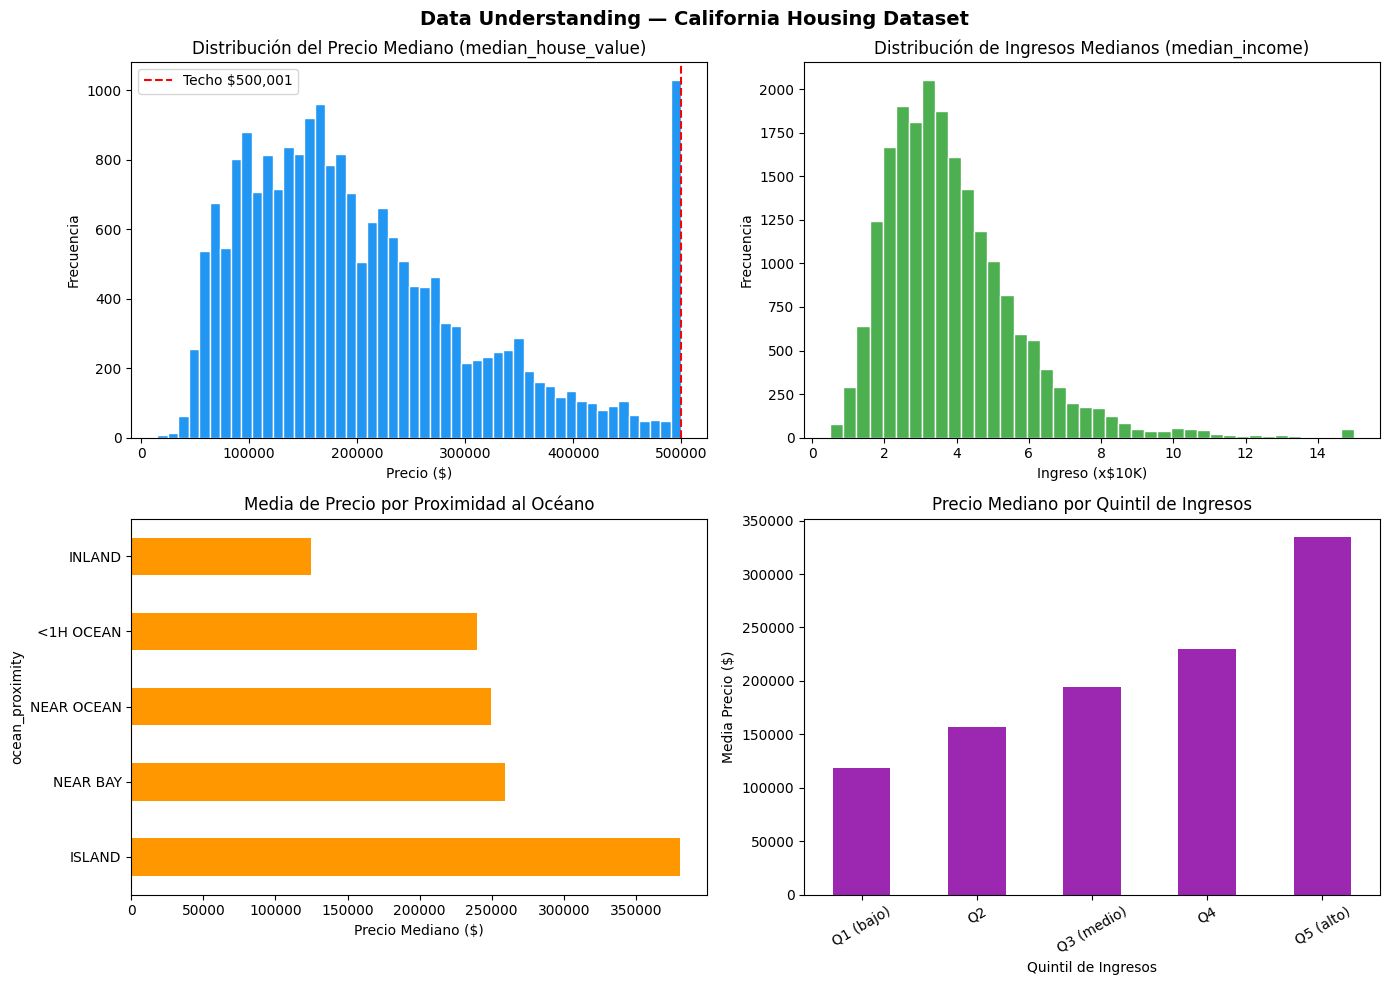

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Data Understanding — California Housing Dataset", fontsize=14, fontweight="bold")

# ── Gráfico 1: Distribución del precio (median_house_value) ─────────────────
axes[0, 0].hist(df["median_house_value"].dropna(), bins=50, color="#2196F3", edgecolor="white")
axes[0, 0].axvline(CAP_HOUSE_VALUE, color="red", linestyle="--", label=f"Techo ${CAP_HOUSE_VALUE:,}")
axes[0, 0].set_title("Distribución del Precio Mediano (median_house_value)")
axes[0, 0].set_xlabel("Precio ($)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].legend()

# ── Gráfico 2: Distribución de median_income ─────────────────────────────────
axes[0, 1].hist(df["median_income"].dropna(), bins=40, color="#4CAF50", edgecolor="white")
axes[0, 1].set_title("Distribución de Ingresos Medianos (median_income)")
axes[0, 1].set_xlabel("Ingreso (x$10K)")
axes[0, 1].set_ylabel("Frecuencia")

# ── Gráfico 3: Media de precio por ocean_proximity ────────────────────────────
media_ocean.plot(kind="barh", ax=axes[1, 0], color="#FF9800")
axes[1, 0].set_title("Media de Precio por Proximidad al Océano")
axes[1, 0].set_xlabel("Precio Mediano ($)")

# ── Gráfico 4: Precio vs. Ingresos por quintil ───────────────────────────────
evolucion_income.plot(kind="bar", ax=axes[1, 1], color="#9C27B0")
axes[1, 1].set_title("Precio Mediano por Quintil de Ingresos")
axes[1, 1].set_xlabel("Quintil de Ingresos")
axes[1, 1].set_ylabel("Media Precio ($)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


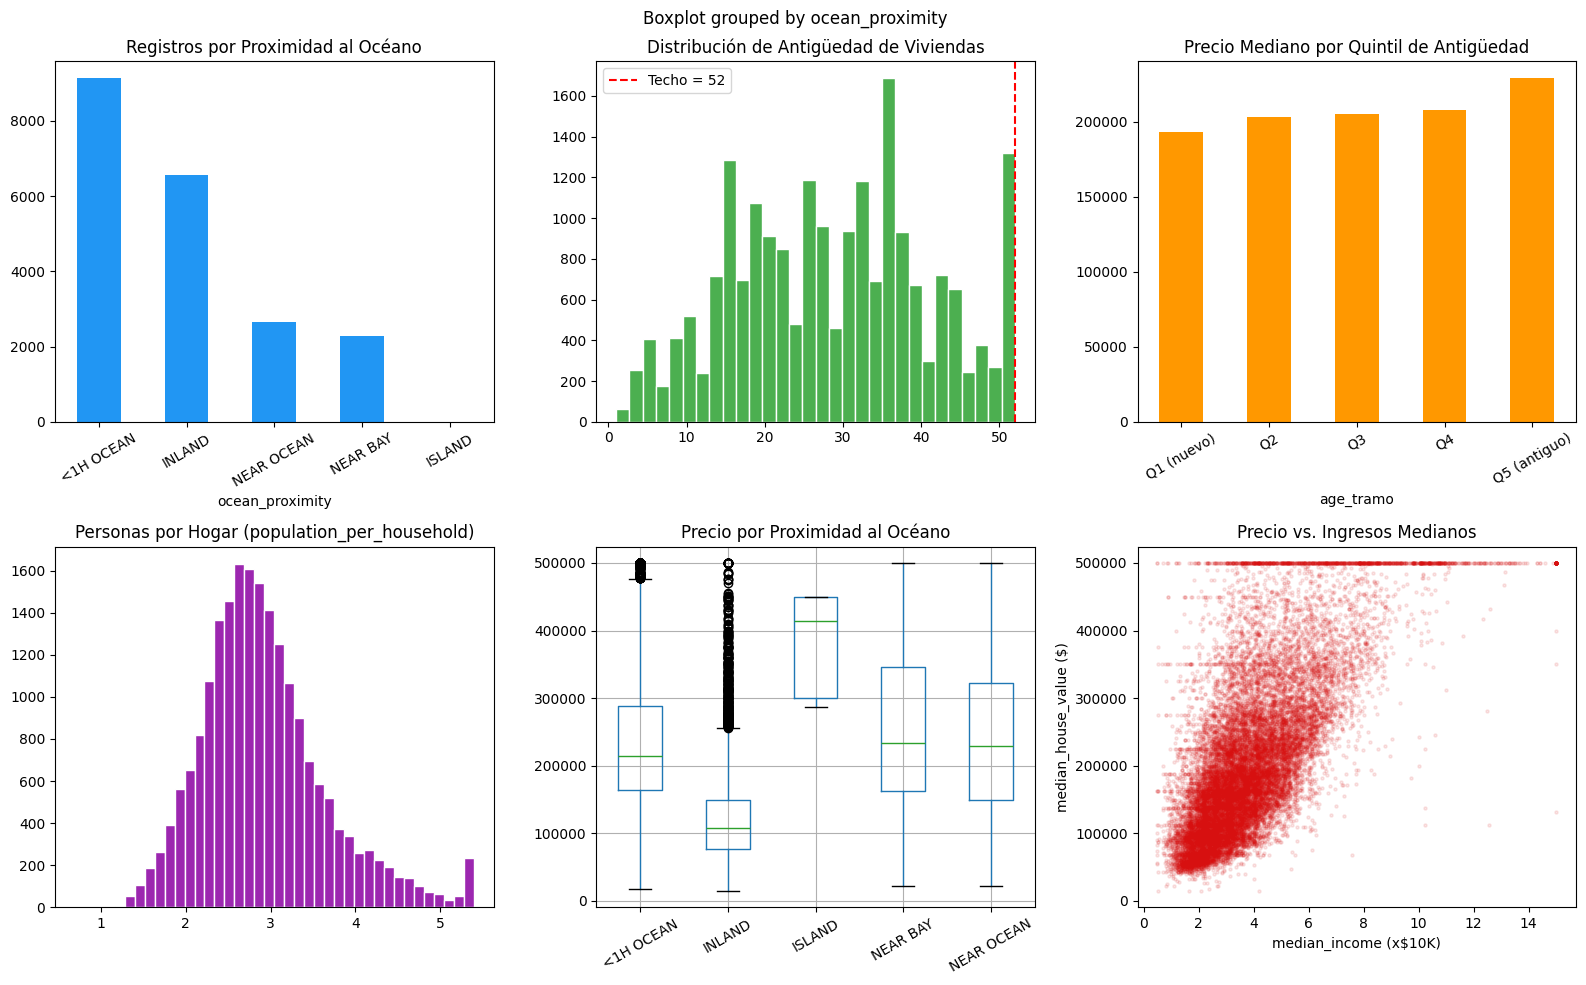

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Data Understanding — Distribución por variables categóricas y geográficas",
             fontsize=14, fontweight="bold")

# ── Gráfico 1: Total de registros por ocean_proximity ────────────────────────
df["ocean_proximity"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#2196F3")
axes[0, 0].set_title("Registros por Proximidad al Océano")
axes[0, 0].tick_params(axis="x", rotation=30)

# ── Gráfico 2: Distribución de housing_median_age ─────────────────────────────
axes[0, 1].hist(df["housing_median_age"].dropna(), bins=30, color="#4CAF50", edgecolor="white")
axes[0, 1].axvline(CAP_MEDIAN_AGE, color="red", linestyle="--", label=f"Techo = {CAP_MEDIAN_AGE}")
axes[0, 1].set_title("Distribución de Antigüedad de Viviendas")
axes[0, 1].legend()

# ── Gráfico 3: Precio mediano por quintil de antigüedad ───────────────────────
df["age_tramo"] = pd.qcut(df["housing_median_age"], q=5,
    labels=["Q1 (nuevo)", "Q2", "Q3", "Q4", "Q5 (antiguo)"])
df.groupby("age_tramo")["median_house_value"].mean().plot(
    kind="bar", ax=axes[0, 2], color="#FF9800")
axes[0, 2].set_title("Precio Mediano por Quintil de Antigüedad")
axes[0, 2].tick_params(axis="x", rotation=30)

# ── Gráfico 4: Distribución de population_per_household ──────────────────────
axes[1, 0].hist(
    df["population_per_household"].clip(upper=df["population_per_household"].quantile(0.99)),
    bins=40, color="#9C27B0", edgecolor="white")
axes[1, 0].set_title("Personas por Hogar (population_per_household)")

# ── Gráfico 5: Precio mediano por ocean_proximity (boxplot) ──────────────────
df.boxplot(column="median_house_value", by="ocean_proximity",
           ax=axes[1, 1], notch=False)
axes[1, 1].set_title("Precio por Proximidad al Océano")
axes[1, 1].set_xlabel("")
plt.sca(axes[1, 1])
plt.xticks(rotation=30)

# ── Gráfico 6: Scatter precio vs. ingresos ────────────────────────────────────
axes[1, 2].scatter(df["median_income"], df["median_house_value"],
                   alpha=0.1, s=5, color="#D71010")
axes[1, 2].set_title("Precio vs. Ingresos Medianos")
axes[1, 2].set_xlabel("median_income (x$10K)")
axes[1, 2].set_ylabel("median_house_value ($)")

plt.tight_layout()
plt.show()


## Correlaciones

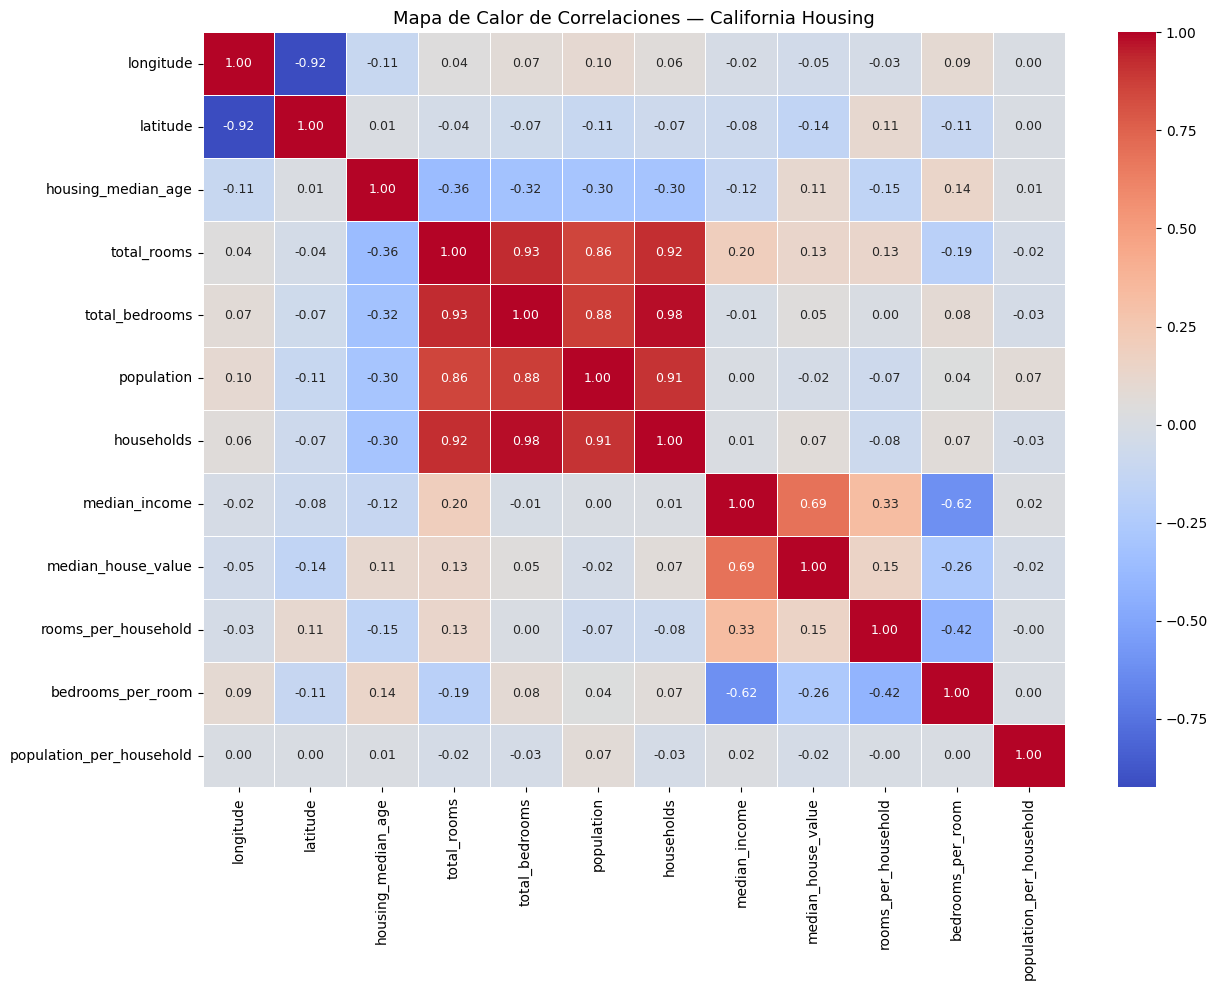

In [45]:
# Mapa de calor de correlaciones entre variables numéricas
# Incluye los ratios derivados para evaluar su potencial predictivo
cols_corr = CAMPOS_NUMERICOS + ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
df_corr = df[cols_corr].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Mapa de Calor de Correlaciones — California Housing", fontsize=13)
plt.tight_layout()
plt.show()


In [46]:
# Correlación de cada variable con el target (median_house_value), ordenada
corr_target = df_corr["median_house_value"].drop("median_house_value").sort_values(ascending=False)
print("  Correlación con median_house_value (de mayor a menor):")
for col, val in corr_target.items():
    barra = "█" * int(abs(val) * 20)
    signo = "+" if val >= 0 else "-"
    print(f"    {col:<35}: {signo}{abs(val):.3f}  {barra}")


  Correlación con median_house_value (de mayor a menor):
    median_income                      : +0.688  █████████████
    rooms_per_household                : +0.152  ███
    total_rooms                        : +0.134  ██
    housing_median_age                 : +0.106  ██
    households                         : +0.066  █
    total_bedrooms                     : +0.050  
    population_per_household           : -0.024  
    population                         : -0.025  
    longitude                          : -0.046  
    latitude                           : -0.144  ██
    bedrooms_per_room                  : -0.256  █████


## 11. Resumen ejecutivo de calidad del dataset

In [47]:
# KPIs de calidad del dataset en una sola tabla de referencia rápida

resumen = {
    "Total de registros": len(df),
    "Campos disponibles": df.shape[1],
    "Campos con nulos": int((df.isnull().sum() > 0).sum()),
    "Registros nulos (total_bedrooms)": int(df["total_bedrooms"].isnull().sum()),
    "Duplicados exactos": int(df.duplicated().sum()),
    f"Registros con precio capado ({CAP_HOUSE_VALUE:,})": int((df["median_house_value"] == CAP_HOUSE_VALUE).sum()),
    f"Registros con edad capada ({CAP_MEDIAN_AGE})": int((df["housing_median_age"] == CAP_MEDIAN_AGE).sum()),
    "Valores únicos ocean_proximity": df["ocean_proximity"].nunique(),
    "Registros ISLAND (categoría minoritaria)": int((df["ocean_proximity"] == "ISLAND").sum()),
    "Correlación median_income vs precio": round(df["median_income"].corr(df["median_house_value"]), 3),
    "Rango median_house_value (min-max)": f"${df['median_house_value'].min():,.0f} – ${df['median_house_value'].max():,.0f}",
    "Rango median_income": f"{df['median_income'].min():.2f} – {df['median_income'].max():.2f} (x$10K)",
}

df_resumen = pd.DataFrame.from_dict(resumen, orient="index", columns=["Valor"])
display(df_resumen)


,Valor
Total de registros,20640
Campos disponibles,15
Campos con nulos,2
Registros nulos (total_bedrooms),207
Duplicados exactos,0
"Registros con precio capado (500,001)",965
Registros con edad capada (52),1273
Valores únicos ocean_proximity,5
Registros ISLAND (categoría minoritaria),5
Correlación median_income vs precio,0.688


In [48]:
# Checklist de próximos pasos antes de pasar al análisis formal

proximos_pasos = [
    "1. Tratar registros con median_house_value == 500,001 (excluir o clase especial)",
    "2. Imputar nulos de total_bedrooms (mediana por ocean_proximity recomendada)",
    "3. Aplicar transformación log a total_rooms, total_bedrooms, population (skew > 3)",
    "4. Evaluar si housing_median_age == 52 debe tratarse como techo o es dato válido",
    "5. Usar ratios derivados (rooms/household, bedrooms/room) en lugar de valores brutos",
    "6. Considerar excluir o agrupar la categoría ISLAND (solo 5 registros)",
    "7. Explorar interacción geográfica (latitude + longitude) mediante clustering o mapas",
    "8. Normalizar median_income a escala real ($) si se comunican resultados a negocio",
]

print("\n✔ Data Understanding completado.\n")
print("  PRÓXIMOS PASOS:")
for paso in proximos_pasos:
    print(f"  {paso}")



✔ Data Understanding completado.

  PRÓXIMOS PASOS:
  1. Tratar registros con median_house_value == 500,001 (excluir o clase especial)
  2. Imputar nulos de total_bedrooms (mediana por ocean_proximity recomendada)
  3. Aplicar transformación log a total_rooms, total_bedrooms, population (skew > 3)
  4. Evaluar si housing_median_age == 52 debe tratarse como techo o es dato válido
  5. Usar ratios derivados (rooms/household, bedrooms/room) en lugar de valores brutos
  6. Considerar excluir o agrupar la categoría ISLAND (solo 5 registros)
  7. Explorar interacción geográfica (latitude + longitude) mediante clustering o mapas
  8. Normalizar median_income a escala real ($) si se comunican resultados a negocio
